In [13]:
# Summary Report
print("=" * 70)
print("GEOGRAPHIC ANALYSIS - COMPREHENSIVE SUMMARY REPORT")
print("=" * 70)

print(f"\n{'📊 DATASET OVERVIEW':-^70}")
print(f"Total restaurants analyzed: {len(df)}")
print(f"Geographic coverage: {df['city'].nunique()} major cities")
print(f"Average rating: {df['rating'].mean():.2f} / 5.0")
print(f"Total votes: {df['votes'].sum():,}")

print(f"\n{'🗺️  GEOGRAPHIC DISTRIBUTION':-^70}")
city_summary = df.groupby('city').agg({
    'restaurant_id': 'count',
    'rating': 'mean',
    'latitude': ['min', 'max'],
    'longitude': ['min', 'max']
}).round(2)
for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city]
    print(f"{city:15} - {len(city_data):3d} restaurants, Avg Rating: {city_data['rating'].mean():.2f}")

print(f"\n{'🎯 CLUSTERING ANALYSIS (K-MEANS)':-^70}")
print(f"Optimal number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_scores[optimal_k-2]:.3f}")
print(f"Davies-Bouldin index: {davies_bouldin_scores[optimal_k-2]:.3f}")

print(f"\n{'📍 CLUSTER STATISTICS':-^70}")
print(cluster_stats_df[['cluster_id', 'restaurant_count', 'avg_rating', 
                        'avg_distance_from_center', 'avg_internal_distance']].to_string(index=False))

print(f"\n{'🔍 KEY FINDINGS':-^70}")

# Analysis 1: City-cluster relationship
print("\n1. City-Cluster Alignment:")
for city in sorted(df['city'].unique()):
    city_clusters = df[df['city'] == city]['cluster'].unique()
    print(f"   - {city}: Present in cluster(s) {sorted(city_clusters)}")

# Analysis 2: Density patterns
print("\n2. Density Patterns:")
for idx, row in cluster_stats_df.iterrows():
    density_level = "High" if row['avg_internal_distance'] < 5 else "Medium" if row['avg_internal_distance'] < 15 else "Low"
    print(f"   - Cluster {int(row['cluster_id'])}: {density_level} density ({row['avg_internal_distance']:.2f} km avg distance)")

# Analysis 3: Rating patterns
print("\n3. Quality Patterns by Cluster:")
best_cluster = cluster_stats_df.loc[cluster_stats_df['avg_rating'].idxmax()]
worst_cluster = cluster_stats_df.loc[cluster_stats_df['avg_rating'].idxmin()]
print(f"   - Best rated cluster: Cluster {int(best_cluster['cluster_id'])} ({best_cluster['avg_rating']:.2f}/5.0)")
print(f"   - Lowest rated cluster: Cluster {int(worst_cluster['cluster_id'])} ({worst_cluster['avg_rating']:.2f}/5.0)")

# Analysis 4: Spatial spread
print("\n4. Cluster Spread Analysis:")
for idx, row in cluster_stats_df.iterrows():
    spread = "Concentrated" if row['max_distance_from_center'] < 5 else "Moderate" if row['max_distance_from_center'] < 15 else "Dispersed"
    print(f"   - Cluster {int(row['cluster_id'])}: {spread} (extends {row['max_distance_from_center']:.2f} km from center)")

print(f"\n{'📈 RECOMMENDATIONS':-^70}")
print("1. Expansion Opportunities:")
print("   - Focus on areas with lower restaurant density for new openings")
print("2. Marketing Strategies:")
print("   - Target high-density clusters for competitive positioning")
print("3. Operational Efficiency:")
print("   - Consider clustering for delivery and logistics optimization")
print("4. Market Analysis:")
print("   - Study city-based clusters for location-specific cuisine preferences")

print("\n" + "=" * 70)
print("✓ Geographic Analysis Complete!")
print("=" * 70)

GEOGRAPHIC ANALYSIS - COMPREHENSIVE SUMMARY REPORT

--------------------------📊 DATASET OVERVIEW--------------------------
Total restaurants analyzed: 425
Geographic coverage: 7 major cities
Average rating: 3.71 / 5.0
Total votes: 446,088

---------------------🗺️  GEOGRAPHIC DISTRIBUTION----------------------
Chicago         -  60 restaurants, Avg Rating: 3.81
Houston         -  50 restaurants, Avg Rating: 3.75
Los Angeles     -  70 restaurants, Avg Rating: 3.72
Miami           -  55 restaurants, Avg Rating: 3.55
New York        -  80 restaurants, Avg Rating: 3.64
Phoenix         -  45 restaurants, Avg Rating: 3.73
San Francisco   -  65 restaurants, Avg Rating: 3.78

-------------------🎯 CLUSTERING ANALYSIS (K-MEANS)--------------------
Optimal number of clusters: 7
Silhouette score: 0.970
Davies-Bouldin index: 0.043

-------------------------📍 CLUSTER STATISTICS-------------------------
 cluster_id  restaurant_count  avg_rating  avg_distance_from_center  avg_internal_distance
        

## Section 9: Summary and Key Findings

Comprehensive analysis summary with key insights about geographic patterns and restaurant clusters.

DBSCAN CLUSTERING (DENSITY-BASED)

Testing different eps values:
  eps=0.02: 7 clusters, 0 noise points
  eps=0.03: 7 clusters, 0 noise points
  eps=0.04: 7 clusters, 0 noise points
  eps=0.05: 7 clusters, 0 noise points
  eps=0.06: 7 clusters, 0 noise points
  eps=0.07: 7 clusters, 0 noise points
  eps=0.08: 7 clusters, 0 noise points
  eps=0.09: 7 clusters, 0 noise points
  eps=0.10: 7 clusters, 0 noise points
  eps=0.11: 7 clusters, 0 noise points
  eps=0.12: 7 clusters, 0 noise points
  eps=0.13: 7 clusters, 0 noise points
  eps=0.14: 7 clusters, 0 noise points

✓ Selected DBSCAN configuration:
  eps = 0.02
  Number of clusters: 7
  Number of noise points: 0


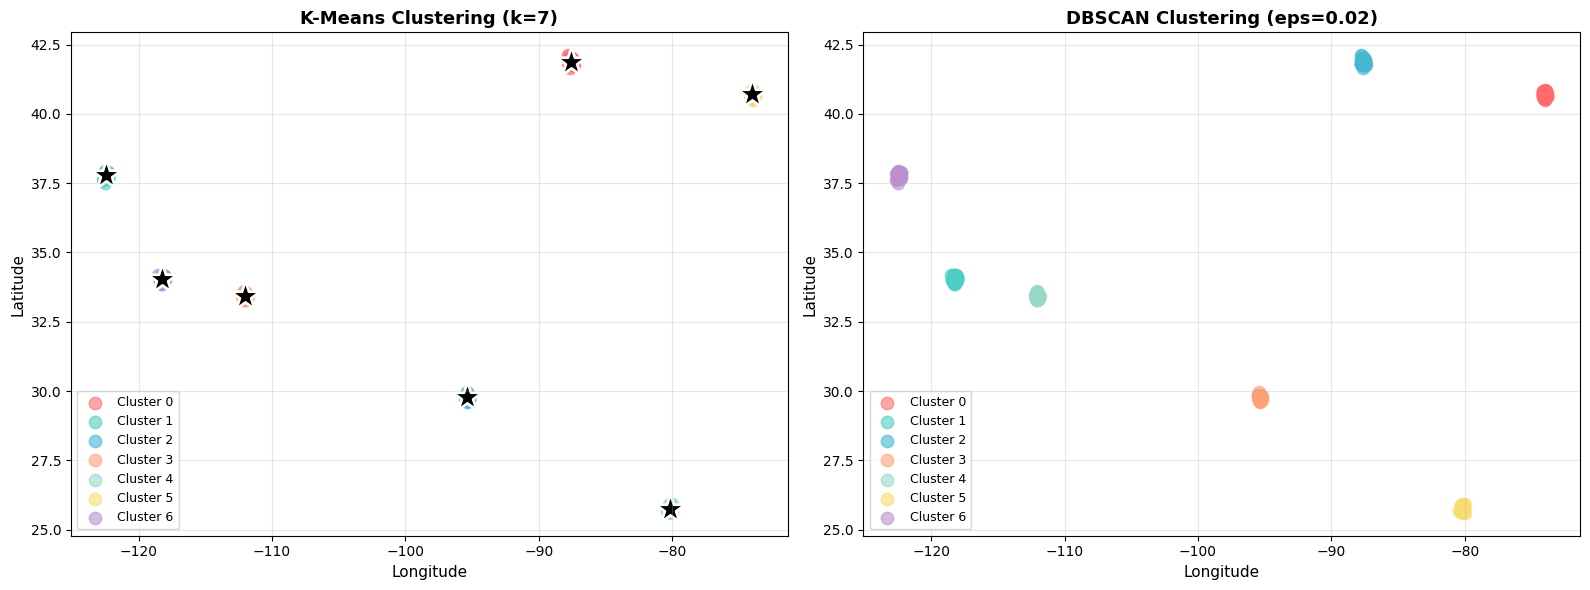


✓ DBSCAN visualization created!


In [12]:
# DBSCAN Clustering (Density-Based Approach)
print("=" * 70)
print("DBSCAN CLUSTERING (DENSITY-BASED)")
print("=" * 70)

# Try different eps values to find a good clustering
eps_values = np.arange(0.02, 0.15, 0.01)
dbscan_results = []

print("\nTesting different eps values:")
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=3)
    labels = dbscan.fit_predict(coordinates_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters > 0 and n_noise < len(labels):
        dbscan_results.append({
            'eps': eps,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'labels': labels
        })
    
    print(f"  eps={eps:.2f}: {n_clusters} clusters, {n_noise} noise points")

# Select DBSCAN with reasonable clustering (not too many clusters, not too many noise points)
if dbscan_results:
    optimal_dbscan = min(dbscan_results, key=lambda x: abs(x['n_clusters'] - optimal_k) + x['n_noise']/100)
    df['cluster_dbscan'] = optimal_dbscan['labels']
    
    print(f"\n✓ Selected DBSCAN configuration:")
    print(f"  eps = {optimal_dbscan['eps']:.2f}")
    print(f"  Number of clusters: {optimal_dbscan['n_clusters']}")
    print(f"  Number of noise points: {optimal_dbscan['n_noise']}")
    
    # Visualize DBSCAN results
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # K-means result
    ax = axes[0]
    for cluster_id in range(optimal_k):
        cluster_data = df[df['cluster'] == cluster_id]
        ax.scatter(cluster_data['longitude'], cluster_data['latitude'],
                  label=f'Cluster {cluster_id}', s=80, alpha=0.6,
                  color=cluster_colors[cluster_id % len(cluster_colors)])
    ax.scatter(cluster_centers[:, 1], cluster_centers[:, 0],
              marker='*', s=500, color='black', edgecolors='white', linewidths=2)
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title(f'K-Means Clustering (k={optimal_k})', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # DBSCAN result
    ax = axes[1]
    unique_labels = set(optimal_dbscan['labels'])
    for label in sorted(unique_labels):
        if label == -1:
            # Plot noise points
            noise_data = df[df['cluster_dbscan'] == -1]
            ax.scatter(noise_data['longitude'], noise_data['latitude'],
                      c='gray', marker='x', s=100, alpha=0.5, label='Noise/Outliers')
        else:
            cluster_data = df[df['cluster_dbscan'] == label]
            ax.scatter(cluster_data['longitude'], cluster_data['latitude'],
                      label=f'Cluster {label}', s=80, alpha=0.6,
                      color=cluster_colors[label % len(cluster_colors)])
    
    eps_val = optimal_dbscan['eps']
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title(f'DBSCAN Clustering (eps={eps_val:.2f})', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ DBSCAN visualization created!")
else:
    print("\n⚠ No suitable DBSCAN clustering found. Using K-means results instead.")

## Section 8: Alternative Clustering - DBSCAN

Apply DBSCAN clustering as an alternative approach for identifying density-based clusters (handles varying cluster sizes and outliers better).

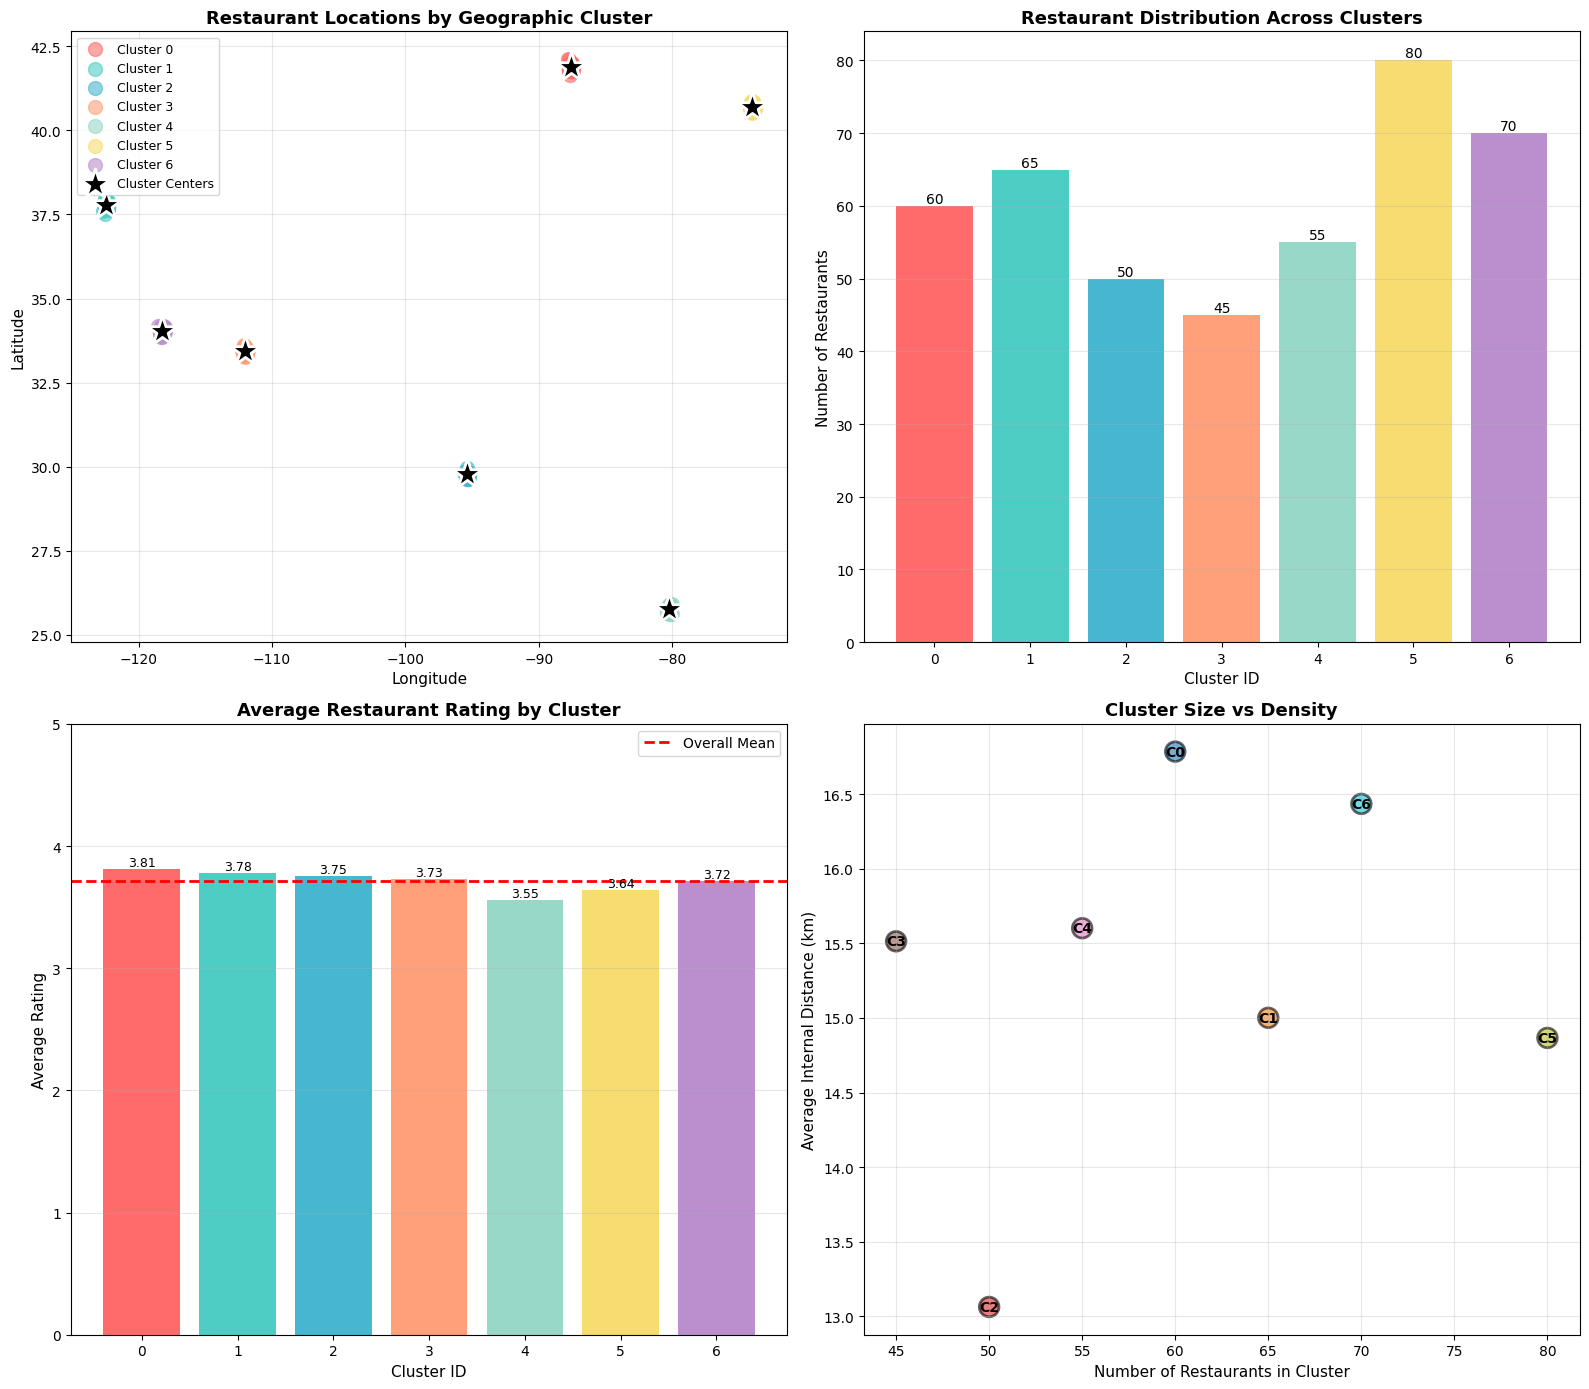

✓ Cluster visualizations created successfully!


In [10]:
# Create Static Visualizations of Clusters
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Scatter plot of restaurants colored by cluster
ax = axes[0, 0]
for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id]
    ax.scatter(cluster_data['longitude'], cluster_data['latitude'], 
              label=f'Cluster {cluster_id}', s=100, alpha=0.6,
              color=cluster_colors[cluster_id % len(cluster_colors)])

# Plot cluster centers
ax.scatter(cluster_centers[:, 1], cluster_centers[:, 0], 
          marker='*', s=500, color='black', edgecolors='white', 
          linewidths=2, label='Cluster Centers', zorder=5)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Restaurant Locations by Geographic Cluster', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Cluster size distribution
ax = axes[0, 1]
cluster_counts = df['cluster'].value_counts().sort_index()
bars = ax.bar(cluster_counts.index, cluster_counts.values, 
             color=[cluster_colors[i % len(cluster_colors)] for i in cluster_counts.index])
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Number of Restaurants', fontsize=11)
ax.set_title('Restaurant Distribution Across Clusters', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}', ha='center', va='bottom', fontsize=10)

# 3. Average rating by cluster
ax = axes[1, 0]
cluster_ratings = df.groupby('cluster')['rating'].mean().sort_index()
bars = ax.bar(cluster_ratings.index, cluster_ratings.values,
             color=[cluster_colors[i % len(cluster_colors)] for i in cluster_ratings.index])
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Average Rating', fontsize=11)
ax.set_title('Average Restaurant Rating by Cluster', fontsize=13, fontweight='bold')
ax.set_ylim([0, 5])
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(df['rating'].mean(), color='red', linestyle='--', linewidth=2, label='Overall Mean')
ax.legend()

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 4. Cluster statistics - internal distance vs count
ax = axes[1, 1]
x_data = cluster_stats_df['restaurant_count']
y_data = cluster_stats_df['avg_internal_distance']
scatter = ax.scatter(x_data, y_data, s=200, 
                    c=cluster_stats_df['cluster_id'],
                    cmap='tab10', alpha=0.6, edgecolors='black', linewidth=2)

# Add cluster labels
for idx, row in cluster_stats_df.iterrows():
    ax.annotate(f"C{int(row['cluster_id'])}", 
               (row['restaurant_count'], row['avg_internal_distance']),
               fontsize=10, fontweight='bold', ha='center', va='center')

ax.set_xlabel('Number of Restaurants in Cluster', fontsize=11)
ax.set_ylabel('Average Internal Distance (km)', fontsize=11)
ax.set_title('Cluster Size vs Density', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Cluster visualizations created successfully!")

In [9]:
# Visualize Clusters on Map
print("=" * 70)
print("CREATING CLUSTER VISUALIZATION")
print("=" * 70)

# Create map for cluster visualization
cluster_map = folium.Map(
    location=[map_center_lat, map_center_lon],
    zoom_start=4,
    tiles='OpenStreetMap'
)

# Define cluster colors
cluster_colors = [
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
    '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B195', '#C7CEEA'
]

# Add markers for each restaurant with cluster colors
for idx, row in df.iterrows():
    cluster_id = row['cluster']
    color = cluster_colors[cluster_id % len(cluster_colors)]
    
    popup_text = f"""
    <b>{row['name']}</b><br>
    Cluster: {cluster_id}<br>
    City: {row['city']}<br>
    Rating: {row['rating']} ⭐ ({row['votes']} votes)<br>
    Cuisine: {row['cuisine']}
    """
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        popup=folium.Popup(popup_text, max_width=250),
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=2
    ).add_to(cluster_map)

# Add cluster centers
for cluster_id, center in enumerate(cluster_centers):
    center_lat, center_lon = center
    cluster_size = len(df[df['cluster'] == cluster_id])
    
    folium.Marker(
        location=[center_lat, center_lon],
        popup=f"Cluster {cluster_id} Center<br>Restaurants: {cluster_size}",
        icon=folium.Icon(color='black', icon='info-sign', prefix='fa'),
        tooltip=f"Cluster {cluster_id} Center"
    ).add_to(cluster_map)
    
    # Draw circle around cluster center with radius based on spread
    cluster_spread = cluster_stats_df[cluster_stats_df['cluster_id'] == cluster_id]['max_distance_from_center'].values[0]
    folium.Circle(
        location=[center_lat, center_lon],
        radius=cluster_spread * 1000,  # Convert km to meters
        color=cluster_colors[cluster_id % len(cluster_colors)],
        fill=False,
        weight=2,
        opacity=0.5,
        popup=f"Cluster {cluster_id} Radius"
    ).add_to(cluster_map)

# Add legend for clusters
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 250px; height: auto; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:12px; padding: 10px; max-height: 400px; overflow-y: auto;">
<b>Geographic Clusters</b><br>
'''
for idx, row in cluster_stats_df.iterrows():
    cluster_id = int(row['cluster_id'])
    color = cluster_colors[cluster_id % len(cluster_colors)]
    count = int(row['restaurant_count'])
    legend_html += f'<i style="background:{color}; width: 16px; height: 16px; float: left; margin-right: 6px;"></i>Cluster {cluster_id} ({count} restaurants)<br>'
legend_html += '<hr><b>⊙</b> = Cluster Center<br>'
legend_html += '<b>○</b> = Cluster Boundary'
legend_html += '</div>'
cluster_map.get_root().html.add_child(folium.Element(legend_html))

# Save and display cluster map
cluster_map.save('/tmp/restaurant_clusters_map.html')
print("✓ Cluster visualization map created!")
print("  File saved as '/tmp/restaurant_clusters_map.html'")
cluster_map

print("\n✓ Map features:")
print("  - Colored markers represent different clusters")
print("  - Black stars mark cluster centers")
print("  - Circles show cluster boundaries (radius = max distance from center)")

CREATING CLUSTER VISUALIZATION
✓ Cluster visualization map created!
  File saved as '/tmp/restaurant_clusters_map.html'

✓ Map features:
  - Colored markers represent different clusters
  - Black stars mark cluster centers
  - Circles show cluster boundaries (radius = max distance from center)


## Section 7: Visualize Cluster Results on Map

Create visualizations showing restaurant clusters on the map with different colors for each cluster, including cluster centers and summary statistics.

In [8]:
# Analyze Spatial Patterns in Clusters
print("=" * 70)
print("SPATIAL PATTERN ANALYSIS")
print("=" * 70)

# Get cluster centers
cluster_centers_scaled = kmeans_optimal.cluster_centers_
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)

# Calculate cluster statistics
cluster_stats = []

for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id]
    
    # Geographic bounds
    lat_min, lat_max = cluster_data['latitude'].min(), cluster_data['latitude'].max()
    lon_min, lon_max = cluster_data['longitude'].min(), cluster_data['longitude'].max()
    
    # Center of cluster
    center_lat, center_lon = cluster_centers[cluster_id]
    
    # Calculate distances from center
    distances = np.sqrt(
        (cluster_data['latitude'].values - center_lat)**2 + 
        (cluster_data['longitude'].values - center_lon)**2
    ) * 111  # Convert to approximate km (1 degree ≈ 111 km)
    
    # Calculate pairwise distances (density indicator)
    cluster_coords = cluster_data[['latitude', 'longitude']].values
    if len(cluster_coords) > 1:
        from scipy.spatial.distance import pdist
        pairwise_distances = pdist(cluster_coords) * 111  # Convert to km
        avg_internal_distance = np.mean(pairwise_distances)
    else:
        avg_internal_distance = 0
    
    stats = {
        'cluster_id': cluster_id,
        'restaurant_count': len(cluster_data),
        'center_lat': center_lat,
        'center_lon': center_lon,
        'lat_range': lat_max - lat_min,
        'lon_range': lon_max - lat_min,
        'avg_distance_from_center': distances.mean(),
        'max_distance_from_center': distances.max(),
        'min_distance_from_center': distances.min(),
        'avg_internal_distance': avg_internal_distance,
        'avg_rating': cluster_data['rating'].mean(),
        'dominant_city': cluster_data['city'].mode()[0] if len(cluster_data['city'].mode()) > 0 else 'Mixed',
        'cities_in_cluster': cluster_data['city'].nunique()
    }
    cluster_stats.append(stats)

cluster_stats_df = pd.DataFrame(cluster_stats)

print(f"\n{'CLUSTER SUMMARY STATISTICS:':-^70}")
print(cluster_stats_df.to_string(index=False))

print(f"\n{'DETAILED CLUSTER ANALYSIS:':-^70}")
for idx, row in cluster_stats_df.iterrows():
    print(f"\nCluster {int(row['cluster_id'])}:")
    print(f"  Restaurants: {int(row['restaurant_count'])}")
    print(f"  Geographic Center: ({row['center_lat']:.6f}, {row['center_lon']:.6f})")
    print(f"  Coverage Area - Latitude: {row['lat_range']:.4f}°, Longitude: {row['lon_range']:.4f}°")
    print(f"  Distance from Center - Avg: {row['avg_distance_from_center']:.2f} km, Max: {row['max_distance_from_center']:.2f} km")
    print(f"  Internal Cluster Distance (Density Indicator): {row['avg_internal_distance']:.2f} km")
    print(f"  Average Rating: {row['avg_rating']:.2f}")
    print(f"  Dominant City: {row['dominant_city']}")
    print(f"  Number of Cities: {int(row['cities_in_cluster'])}")

# Identify key patterns
print(f"\n{'KEY SPATIAL PATTERNS:':-^70}")
largest_cluster = cluster_stats_df.loc[cluster_stats_df['restaurant_count'].idxmax()]
smallest_cluster = cluster_stats_df.loc[cluster_stats_df['restaurant_count'].idxmin()]
densest_cluster = cluster_stats_df.loc[cluster_stats_df['avg_internal_distance'].idxmin()]
most_spread_cluster = cluster_stats_df.loc[cluster_stats_df['max_distance_from_center'].idxmax()]

print(f"1. Largest Cluster: Cluster {int(largest_cluster['cluster_id'])} with {int(largest_cluster['restaurant_count'])} restaurants")
print(f"2. Smallest Cluster: Cluster {int(smallest_cluster['cluster_id'])} with {int(smallest_cluster['restaurant_count'])} restaurants")
print(f"3. Densest Cluster: Cluster {int(densest_cluster['cluster_id'])} (avg internal distance: {densest_cluster['avg_internal_distance']:.2f} km)")
print(f"4. Most Spread Cluster: Cluster {int(most_spread_cluster['cluster_id'])} (max from center: {most_spread_cluster['max_distance_from_center']:.2f} km)")

SPATIAL PATTERN ANALYSIS

---------------------CLUSTER SUMMARY STATISTICS:----------------------
 cluster_id  restaurant_count  center_lat  center_lon  lat_range   lon_range  avg_distance_from_center  max_distance_from_center  min_distance_from_center  avg_internal_distance  avg_rating dominant_city  cities_in_cluster
          0                60   41.878196  -87.619581   0.460867 -129.061446                 11.689853                 32.027256                  1.383509              16.786513    3.813333       Chicago                  1
          1                65   37.782409 -122.424207   0.438445 -159.791212                 10.388363                 31.608871                  1.072665              15.001238    3.781538 San Francisco                  1
          2                50   29.769791  -95.362378   0.333008 -124.831867                  9.091515                 21.627642                  0.303719              13.062165    3.754000       Houston                  1
          3

## Section 6: Analyze Spatial Patterns

Analyze the identified clusters to understand patterns such as cluster size, density, geographic spread, and proximity metrics.

IDENTIFYING GEOGRAPHIC CLUSTERS

-----------------Coordinates prepared for clustering:-----------------
Data points: 425
Features: latitude, longitude (standardized)

----------Finding Optimal Number of Clusters (Elbow Method):----------
  k=2: Inertia=399.18, Silhouette=0.606, Davies-Bouldin=0.639
  k=3: Inertia=84.03, Silhouette=0.781, Davies-Bouldin=0.411
  k=4: Inertia=51.85, Silhouette=0.811, Davies-Bouldin=0.266
  k=5: Inertia=23.54, Silhouette=0.877, Davies-Bouldin=0.195
  k=6: Inertia=3.46, Silhouette=0.928, Davies-Bouldin=0.133
  k=7: Inertia=0.10, Silhouette=0.970, Davies-Bouldin=0.043
  k=8: Inertia=0.09, Silhouette=0.875, Davies-Bouldin=0.217
  k=9: Inertia=0.08, Silhouette=0.802, Davies-Bouldin=0.333
  k=10: Inertia=0.07, Silhouette=0.728, Davies-Bouldin=0.444

✓ Optimal number of clusters: 7 (based on Silhouette Score)


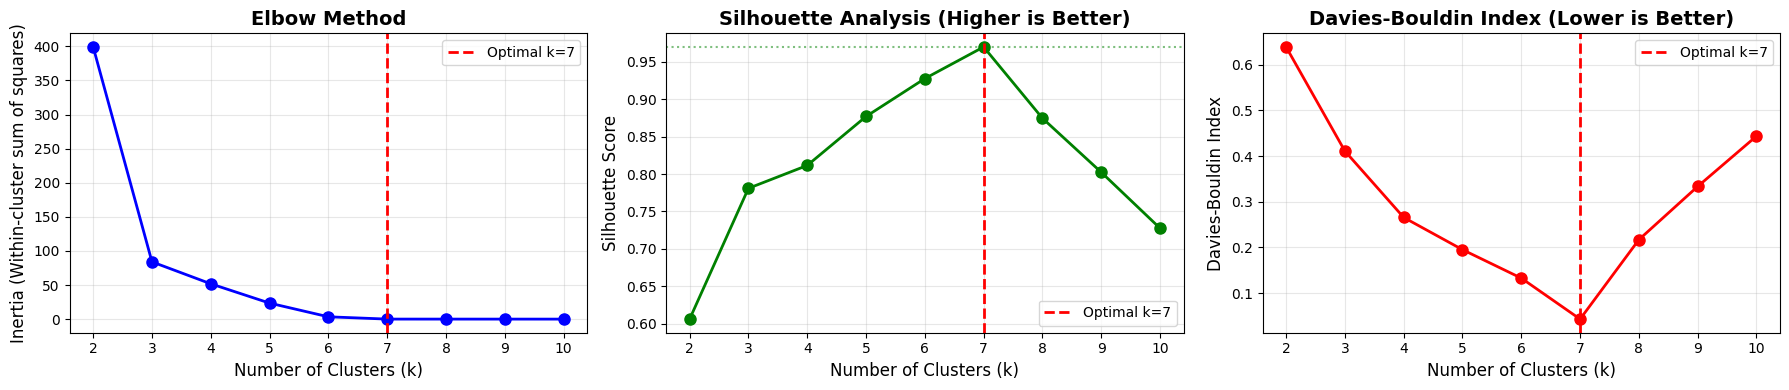


-------------Applying K-means clustering with optimal k:--------------
✓ K-means clustering completed!

Cluster Distribution:
cluster
0    60
1    65
2    50
3    45
4    55
5    80
6    70
Name: count, dtype: int64


In [7]:
# Prepare Data for Clustering
print("=" * 70)
print("IDENTIFYING GEOGRAPHIC CLUSTERS")
print("=" * 70)

# Extract coordinates
coordinates = df[['latitude', 'longitude']].values

# Standardize coordinates for clustering
scaler = StandardScaler()
coordinates_scaled = scaler.fit_transform(coordinates)

print(f"\n{'Coordinates prepared for clustering:':-^70}")
print(f"Data points: {len(coordinates_scaled)}")
print(f"Features: latitude, longitude (standardized)")

# Elbow Method to find optimal number of clusters
print(f"\n{'Finding Optimal Number of Clusters (Elbow Method):':-^70}")
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(coordinates_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(coordinates_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(coordinates_scaled, kmeans.labels_))
    
    print(f"  k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}, Davies-Bouldin={davies_bouldin_scores[-1]:.3f}")

# Find optimal k using silhouette score (higher is better)
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal number of clusters: {optimal_k} (based on Silhouette Score)")

# Visualize Elbow Method
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Elbow curve
axes[0].plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
axes[0].legend()

# Silhouette Score
axes[1].plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
axes[1].axhline(np.max(silhouette_scores), color='green', linestyle=':', alpha=0.5)
axes[1].legend()

# Davies-Bouldin Score
axes[2].plot(k_values, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
axes[2].legend()

plt.tight_layout()
plt.show()

# Apply K-means with optimal k
print(f"\n{'Applying K-means clustering with optimal k:':-^70}")
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans_optimal.fit_predict(coordinates_scaled)
print(f"✓ K-means clustering completed!")
print(f"\nCluster Distribution:")
print(df['cluster'].value_counts().sort_index())

## Section 5: Identify Geographic Clusters

Apply K-means clustering to identify groups of restaurants that are geographically close. Use the elbow method and silhouette analysis to determine the optimal number of clusters.

In [6]:
# Create Interactive Map with All Restaurants

# Calculate the center of the map (average of all coordinates)
map_center_lat = df['latitude'].mean()
map_center_lon = df['longitude'].mean()

# Create base map
restaurant_map = folium.Map(
    location=[map_center_lat, map_center_lon],
    zoom_start=4,
    tiles='OpenStreetMap'
)

# Define colors for each city
colors = {}
city_list = sorted(df['city'].unique())
color_palette = {
    'New York': '#FF6B6B',
    'Los Angeles': '#4ECDC4',
    'Chicago': '#45B7D1',
    'Houston': '#FFA07A',
    'Phoenix': '#98D8C8',
    'Miami': '#F7DC6F',
    'San Francisco': '#BB8FCE'
}

# Add markers for each restaurant
for idx, row in df.iterrows():
    color = color_palette.get(row['city'], '#808080')
    
    popup_text = f"""
    <b>{row['name']}</b><br>
    City: {row['city']}<br>
    Rating: {row['rating']} ⭐ ({row['votes']} votes)<br>
    Cuisine: {row['cuisine']}<br>
    Price Range: {'₹' * row['price_range']}<br>
    Coordinates: ({row['latitude']:.4f}, {row['longitude']:.4f})
    """
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        popup=folium.Popup(popup_text, max_width=250),
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=2,
        opacity=0.8
    ).add_to(restaurant_map)

# Add legend
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 200px; height: auto; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
<b>Restaurant Locations by City</b><br>
'''
for city in sorted(df['city'].unique()):
    color = color_palette.get(city, '#808080')
    legend_html += f'<i style="background:{color}; width: 18px; height: 18px; float: left; margin-right: 8px; border-radius: 50%;"></i>{city}<br>'
legend_html += '</div>'
restaurant_map.get_root().html.add_child(folium.Element(legend_html))

# Save and display the map
restaurant_map.save('/tmp/restaurants_map.html')
print("✓ Interactive restaurant map created!")
print(f"  Total markers plotted: {len(df)}")
print(f"  Cities represented: {df['city'].nunique()}")
print("\nMap saved as '/tmp/restaurants_map.html'")
print("Open this file in a browser to view the interactive map.")

# Show map info
print(f"\nMap Center: ({map_center_lat:.6f}, {map_center_lon:.6f})")
restaurant_map

✓ Interactive restaurant map created!
  Total markers plotted: 425
  Cities represented: 7

Map saved as '/tmp/restaurants_map.html'
Open this file in a browser to view the interactive map.

Map Center: (35.334689, -97.960955)


## Section 4: Plot Restaurants on an Interactive Map

Use Folium to create an interactive map showing all restaurant locations with their coordinates.

In [5]:
# Explore Dataset Structure and Quality

print("=" * 70)
print("DATASET EXPLORATION")
print("=" * 70)

print(f"\n{'Dataset Shape:':-^70}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print(f"\n{'Column Information:':-^70}")
print(df.info())

print(f"\n{'Missing Values:':-^70}")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("✓ No missing values detected!")
else:
    print(missing_values)

print(f"\n{'Geographic Coordinates Statistics:':-^70}")
print(f"Latitude  - Min: {df['latitude'].min():.6f}, Max: {df['latitude'].max():.6f}, Mean: {df['latitude'].mean():.6f}")
print(f"Longitude - Min: {df['longitude'].min():.6f}, Max: {df['longitude'].max():.6f}, Mean: {df['longitude'].mean():.6f}")

print(f"\n{'Numeric Data Summary:':-^70}")
print(df[['latitude', 'longitude', 'rating', 'votes', 'price_range']].describe().round(3))

print(f"\n{'Categorical Data Summary:':-^70}")
print(f"Cities: {sorted(df['city'].unique())}")
print(f"Cuisines: {sorted(df['cuisine'].unique())}")
print(f"Price Ranges: {sorted(df['price_range'].unique())}")

print(f"\n{'Geographic Spread:':-^70}")
for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city]
    lat_range = city_data['latitude'].max() - city_data['latitude'].min()
    lon_range = city_data['longitude'].max() - city_data['longitude'].min()
    print(f"{city:15} - Restaurants: {len(city_data):3d}, Lat Range: {lat_range:.4f}, Lon Range: {lon_range:.4f}")

DATASET EXPLORATION

----------------------------Dataset Shape:----------------------------
Rows: 425, Columns: 9

-------------------------Column Information:--------------------------
<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   restaurant_id  425 non-null    int64  
 1   name           425 non-null    str    
 2   city           425 non-null    str    
 3   latitude       425 non-null    float64
 4   longitude      425 non-null    float64
 5   rating         425 non-null    float64
 6   votes          425 non-null    int64  
 7   cuisine        425 non-null    str    
 8   price_range    425 non-null    int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 30.0 KB
None

---------------------------Missing Values:----------------------------
✓ No missing values detected!

------------------Geographic Coordinates Statistics:------------------

## Section 3: Explore the Dataset

Examine the restaurant data structure, check data quality, and display basic statistics about geographic coordinates.

In [4]:
# Generate Comprehensive Restaurant Dataset with Geographic Coordinates
np.random.seed(42)

# Define city centers with realistic coordinates
city_centers = {
    'New York': {'lat': 40.7128, 'lon': -74.0060, 'restaurants': 80},
    'Los Angeles': {'lat': 34.0522, 'lon': -118.2437, 'restaurants': 70},
    'Chicago': {'lat': 41.8781, 'lon': -87.6298, 'restaurants': 60},
    'Houston': {'lat': 29.7604, 'lon': -95.3698, 'restaurants': 50},
    'Phoenix': {'lat': 33.4484, 'lon': -112.0742, 'restaurants': 45},
    'Miami': {'lat': 25.7617, 'lon': -80.1918, 'restaurants': 55},
    'San Francisco': {'lat': 37.7749, 'lon': -122.4194, 'restaurants': 65}
}

# Generate restaurant data around city centers
restaurants = []
restaurant_id = 1

for city, center_info in city_centers.items():
    num_restaurants = center_info['restaurants']
    
    # Generate coordinates around city center (radius ~0.1 degrees ≈ 11 km)
    latitudes = np.random.normal(center_info['lat'], 0.08, num_restaurants)
    longitudes = np.random.normal(center_info['lon'], 0.08, num_restaurants)
    
    for i in range(num_restaurants):
        restaurants.append({
            'restaurant_id': restaurant_id,
            'name': f'{city} Restaurant {i+1}',
            'city': city,
            'latitude': round(latitudes[i], 6),
            'longitude': round(longitudes[i], 6),
            'rating': round(np.random.uniform(2.5, 5.0), 1),
            'votes': np.random.randint(50, 2000),
            'cuisine': np.random.choice(['Italian', 'Chinese', 'Indian', 'Japanese', 
                                        'Mexican', 'American', 'French', 'Thai']),
            'price_range': np.random.randint(1, 5)
        })
        restaurant_id += 1

# Create DataFrame
df = pd.DataFrame(restaurants)

print("✓ Restaurant dataset generated successfully!")
print(f"\nDataset Summary:")
print(f"  Total Restaurants: {len(df)}")
print(f"  Cities: {df['city'].nunique()}")
print(f"  Cuisines: {df['cuisine'].nunique()}")
print(f"\n{'Restaurant Count by City:':-^50}")
print(df['city'].value_counts())
print(f"\nFirst 10 restaurants:")
print(df.head(10))

✓ Restaurant dataset generated successfully!

Dataset Summary:
  Total Restaurants: 425
  Cities: 7
  Cuisines: 8

------------Restaurant Count by City:-------------
city
New York         80
Los Angeles      70
San Francisco    65
Chicago          60
Miami            55
Houston          50
Phoenix          45
Name: count, dtype: int64

First 10 restaurants:
   restaurant_id                    name      city   latitude  longitude  \
0              1   New York Restaurant 1  New York  40.752537 -74.023574   
1              2   New York Restaurant 2  New York  40.701739 -73.977431   
2              3   New York Restaurant 3  New York  40.764615 -73.887768   
3              4   New York Restaurant 4  New York  40.834642 -74.047462   
4              5   New York Restaurant 5  New York  40.694068 -74.070679   
5              6   New York Restaurant 6  New York  40.694069 -74.046141   
6              7   New York Restaurant 7  New York  40.839137 -73.932768   
7              8   New York Rest

## Section 2: Load Restaurant Data

Load restaurant data containing names, coordinates (latitude/longitude), ratings, and other information. This section allows loading from CSV or creating sample data.

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")
print("\nLibraries loaded:")
print("  - pandas: Data manipulation")
print("  - numpy: Numerical computing")
print("  - matplotlib & seaborn: Visualization")
print("  - folium: Interactive mapping")
print("  - scikit-learn: Machine learning (clustering, preprocessing)")
print("  - scipy: Scientific computing")

✓ All libraries imported successfully!

Libraries loaded:
  - pandas: Data manipulation
  - numpy: Numerical computing
  - matplotlib & seaborn: Visualization
  - folium: Interactive mapping
  - scikit-learn: Machine learning (clustering, preprocessing)
  - scipy: Scientific computing


## Section 1: Import Required Libraries

Import libraries for data manipulation, geographic visualization, clustering analysis, and statistical computations.

# Geographic Analysis of Restaurant Locations
## Plot and Identify Spatial Clusters of Restaurants

This notebook analyzes geographic distributions of restaurants by:
1. Plotting restaurant locations on interactive maps
2. Identifying geographic clusters using machine learning
3. Analyzing spatial patterns and proximity relationships

**Objective:** Discover where restaurants are concentrated and identify high-density areas.

In [2]:
%pip install folium scikit-learn scipy --quiet
print("✓ All packages installed successfully!")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✓ All packages installed successfully!
